# S2 Coursework DRAFT

## Question 1: Accident data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
mining_data = np.loadtxt(os.path.join('data','coal_mining_accident_data.dat'))
flattened_data = np.ndarray.flatten(mining_data, order="C")
flattened_data_cumulative = np.cumsum(flattened_data)

total_period = 40550
total_events = 191

number_of_accidents = np.arange(0, len(flattened_data_cumulative), 1)

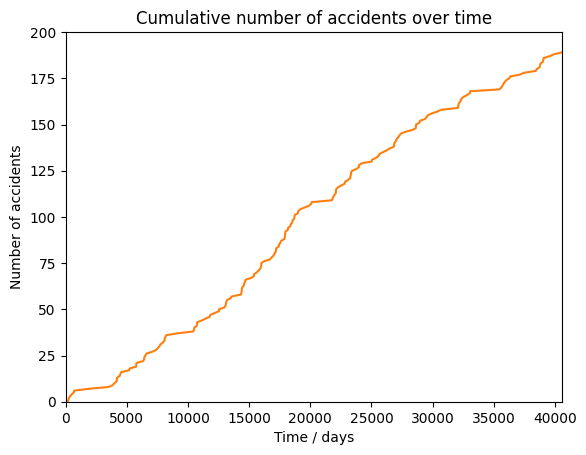

In [3]:
plt.plot(flattened_data_cumulative, number_of_accidents, color="tab:orange")
plt.xlabel("Time / days")
plt.ylabel("Number of accidents")
plt.title("Cumulative number of accidents over time")
plt.xlim(0,40550)
plt.ylim(0,200)
plt.show()

In [4]:
mean_rate = total_events / (total_period)
print(f"Mean rate of accidents: {mean_rate:.4f} per day")
mean_rate_year = number_of_accidents[-1] / (total_period / 365) # Convert total period from years to days
print(f"Mean rate of accidents: {mean_rate_year:.2f} per year")

Mean rate of accidents: 0.0047 per day
Mean rate of accidents: 1.70 per year


## Question 2: Priors

### (a)

(4,)
[ 9366.79709019  9537.96790587 20096.71723745 29744.04156837]
(4,)
[ 7216.17671048 11514.79957495 16262.5680221  22063.73068001]


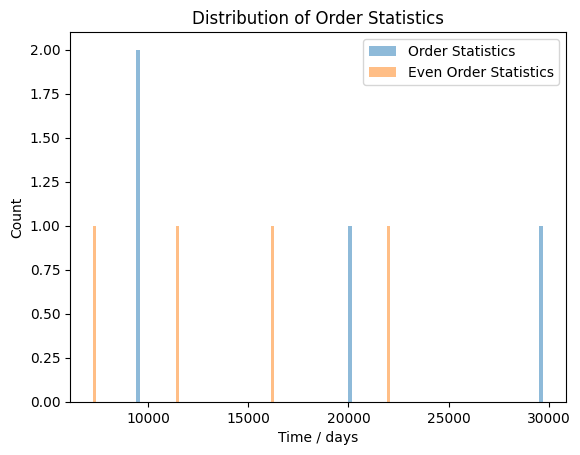

In [5]:
from scipy import special

def gamma(x, alpha, beta):
    pdf = (beta ** alpha) * np.exp(-beta * x) / special.gamma(alpha)
    return pdf

k = 4
order_statistics = np.sort(np.random.uniform(0, total_period, k))
print(np.shape(order_statistics))
print(order_statistics)
even_order_statistics = np.sort(np.random.uniform(0, total_period, 2 * k + 1))[1:-1:2]
print(np.shape(even_order_statistics))
print(even_order_statistics)

plt.hist(order_statistics, bins=100, density=False, alpha=0.5, label='Order Statistics')
plt.hist(even_order_statistics, bins=100, density=False, alpha=0.5, label='Even Order Statistics')
plt.xlabel("Time / days")
plt.ylabel("Count")
plt.title("Distribution of Order Statistics")
plt.legend()
plt.show()

## Question 3: The constant rate model

### (a)

The prior on $h_0$ is 

\begin{equation}
    \pi(h_0|M_0)=\beta^\alpha\exp(-\beta h)/\Gamma(\alpha),
\end{equation}

where $\alpha=1$, $\beta=200\;\text{days}$. In the constant rate case, the log-likelihood is simply

\begin{equation}
    \log\mathcal{L}(\{I_i\}|h_0,M_0)=N\log h_0-h_0L.
\end{equation}

The posterior on $h_0$ is thus

\begin{equation}
    P(h_0|\{I_i\}, M_0)=200h_0^N\exp(-h_0(200+L)).
\end{equation}

In [6]:
alpha = 1
beta = 200

def constant_rate_prior(h, alpha, beta):
    return beta ** alpha * np.exp(-beta * h) / special.gamma(alpha)

def log_constant_rate_prior(h, alpha, beta):
    return alpha * np.log(beta) - beta * h - special.gammaln(alpha)

def constant_rate_likelihood(h):
    return h ** total_events * np.exp(-h * total_period)

def log_constant_rate_likelihood(h):
    return total_events * np.log(h) - h * total_period

def constant_rate_posterior(h, alpha, beta):
    return constant_rate_prior(h, alpha, beta) * constant_rate_likelihood(h) * model_prior(0)

def log_constant_rate_posterior(h, alpha, beta):
    return log_constant_rate_prior(h, alpha, beta) + log_constant_rate_likelihood(h)

/tmp/ipykernel_32126/769097394.py:14: RuntimeWarning: divide by zero encountered in log
  return total_events * np.log(h) - h * total_period


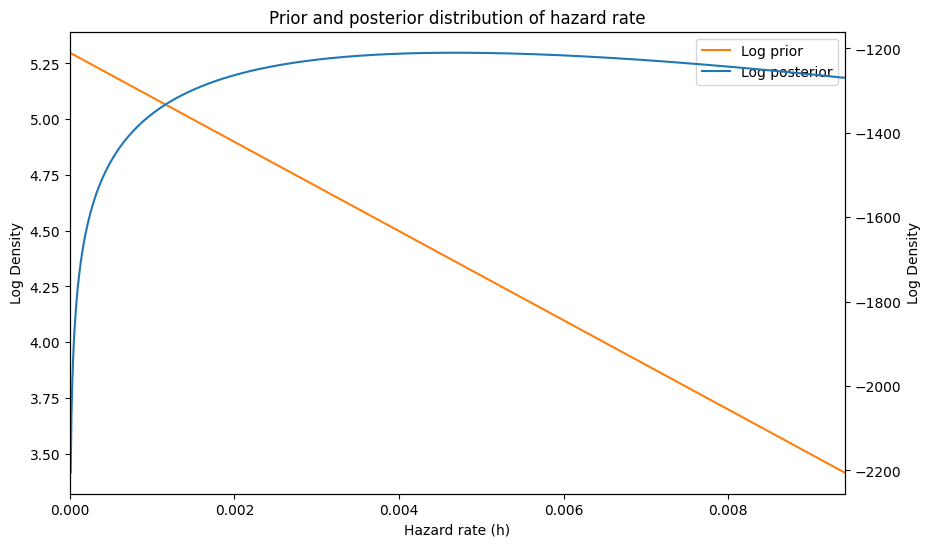

In [7]:
h_values = np.linspace(0, 191 * 2 / 40550, 1000)
log_posterior_values = log_constant_rate_posterior(h_values, alpha, beta)
log_prior_values = log_constant_rate_prior(h_values, alpha, beta)

fig, ax = plt.subplots(figsize=(10, 6))
ax2 = ax.twinx()
p1 = ax.plot(h_values, log_prior_values, color="tab:orange", label="Log prior")
p2 = ax2.plot(h_values, log_posterior_values, color="tab:blue", label="Log posterior")

ax.set_xlabel("Hazard rate (h)")
ax.set_ylabel("Log Density")
ax.set_title("Prior and posterior distribution of hazard rate")
ax.set_xlim(0, 191 * 2 / 40550)
ax2.set_ylabel("Log Density")

ps = p1 + p2
labels = [p.get_label() for p in ps]
ax.legend(ps, labels, loc=0)

plt.show()

Computing the evidence from the unnormalised posterior requires scaling the integrand by a constant to avoid underflow errors. The evidence is given by

\begin{equation}
    Z=\int_0^\infty 200h_0^N\exp(-h_0(200+L))dh_0.
\end{equation}

We can compute the maximum of the log-integrand, which turns out to be at $h_0=\frac{N}{200+L}$. Subtracting the log-integrand evaluated at this point we get

\begin{equation}
    \log\tilde{P}=\log P+\text{const}=N(\log\frac{h_0(200+L)}{N}+1)-h_0(200+L),
\end{equation}

where $\text{const}=\log(200(\frac{N}{200+L})^N)\exp(-N)$. With this, the evidence is given by

\begin{equation}
    Z=\exp(-\text{const})\int\exp\tilde{P}dh_0.
\end{equation}

In [8]:
from scipy.integrate import quad

def exp_scaled_log_integrand(h):
    return np.exp(total_events * (np.log(h * (200 + total_period)/total_events) + 1) - h * (200 + total_period))

scaled_evidence, _ = quad(exp_scaled_log_integrand, 0, 1)
print(f"Scaled evidence: {scaled_evidence:.10e}")

Scaled evidence: 8.5048858166e-04


The prefactor in the evidence $\exp(\text{const})$ is tiny. With the given parameters, it evaluates to

\begin{equation}
    200\biggl(\frac{191}{40750}\biggr)^{191}\exp(-191) = 3.12\times10^{-526}.
\end{equation}

As a result, the total evidence is

\begin{equation}
    Z=2.65\times10^{-529},
\end{equation}

\begin{equation}
    \log Z=-1217.09.
\end{equation}

## Question 4: The 1 change point model

### (a)

I have used the package `emcee`.

In [57]:
import emcee

alpha = 1
beta = 200

# The change point s_1 is a parameter of the model. The others are h_0 and h_1. We need to count the number of accidents occuring before and after the change
# point s_1, denoted n_0 and n_1 respectively. We also need to calculate the total time spent before and after the change point, denoted T_0 and T_1 
# respectively. The likelihood of the data given the parameters can be expressed as:
# L(h_0, h_1, s_1) = (h_0^n_0 * exp(-h_0 * T_0)) * (h_1^n_1 * exp(-h_1 * T_1))

def log_likelihood(h_0, h_1, s_1):
    n_0 = np.sum(flattened_data_cumulative < s_1)
    n_1 = np.sum(flattened_data_cumulative > s_1)
    T_0 = s_1
    T_1 = total_period - s_1
    log_likelihood_value = n_0 * np.log(h_0) - h_0 * T_0 + n_1 * np.log(h_1) - h_1 * T_1
    if h_0 <= 0 or h_1 <= 0 or s_1 <= 0 or s_1 >= total_period:
        return -np.inf  # Log of zero probability
    else:
        return log_likelihood_value

def log_prior(h_0, h_1, s_1):
    if h_0 <= 0 or h_1 <= 0 or s_1 <= 0 or s_1 >= total_period:
        return -np.inf  # Log of zero probability
    else:
        return alpha * np.log(beta) - beta * h_0 + alpha * np.log(beta) - beta * h_1 + np.log(s_1) + np.log(total_period - s_1) - 3 * np.log(total_period)
    
def log_posterior(params):
    h_0, h_1, s_1 = params
    return log_prior(h_0, h_1, s_1) + log_likelihood(h_0, h_1, s_1)

ndim = 3
nwalkers = 50
nsteps = 20000
nburnin = 2000

# Initialize walkers around estimated sensible values
# s1 ~ L/2, h ~ N/L
start_pos = np.zeros((nwalkers, ndim))
start_pos[:, 0] = np.random.uniform(10000, 30000, nwalkers)  # s1
start_pos[:, 1] = np.random.normal(0.005, 0.001, nwalkers)   # h0
start_pos[:, 2] = np.random.normal(0.002, 0.001, nwalkers)   # h1

# Ensure starting positions are strictly positive for h0, h1
start_pos[:, 1:] = np.abs(start_pos[:, 1:])

sampler_1 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler_1.run_mcmc(start_pos, nsteps, progress=True)
autocorrtime_1 = sampler_1.get_autocorr_time()
print(f"Autocorrelation time for sampler 1: {autocorrtime_1}")
thinning_factor_1 = int(autocorrtime.max())
samples_1 = sampler_1.get_chain(discard=nburnin, thin=thinning_factor_1, flat=True)

sampler_2 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
sampler_2.run_mcmc(start_pos, nsteps, progress=True)
autocorrtime_2 = sampler_2.get_autocorr_time()
print(f"Autocorrelation time for sampler 2: {autocorrtime_2}")
thinning_factor_2 = int(autocorrtime_2.max())
samples_2 = sampler_2.get_chain(discard=nburnin, thin=thinning_factor_2, flat=True)

# Compute GR statistic between the two samples
def gelman_rubin(chains):
    m = len(chains)  # number of chains
    n = len(chains[0])  # number of samples per chain
    mean_per_chain = np.mean(chains, axis=1)
    overall_mean = np.mean(mean_per_chain)
    
    # Between-chain variance
    B = n * np.var(mean_per_chain, ddof=1)
    
    # Within-chain variance
    W = np.mean([np.var(chain, ddof=1) for chain in chains])
    
    # Estimate of the marginal posterior variance
    var_hat = (n - 1) / n * W + B / n
    
    # Potential scale reduction factor
    R_hat = np.sqrt(var_hat / W)
    
    return R_hat

chains = [samples_1[:, i] for i in range(ndim)] + [samples_2[:, i] for i in range(ndim)]
R_hat = gelman_rubin(chains)
print(f"Gelman-Rubin statistic: {R_hat}")

  0%|          | 0/20000 [00:00<?, ?it/s]/tmp/ipykernel_32126/1718530238.py:16: RuntimeWarning: invalid value encountered in log
  log_likelihood_value = n_0 * np.log(h_0) - h_0 * T_0 + n_1 * np.log(h_1) - h_1 * T_1
100%|██████████| 20000/20000 [00:14<00:00, 1350.09it/s]


Autocorrelation time for sampler 1: [ 22.49683048 127.48183157 248.18557096]


100%|██████████| 20000/20000 [00:13<00:00, 1492.39it/s]


Autocorrelation time for sampler 2: [ 22.49683048 127.48183157 248.18557096]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (6,) + inhomogeneous part.

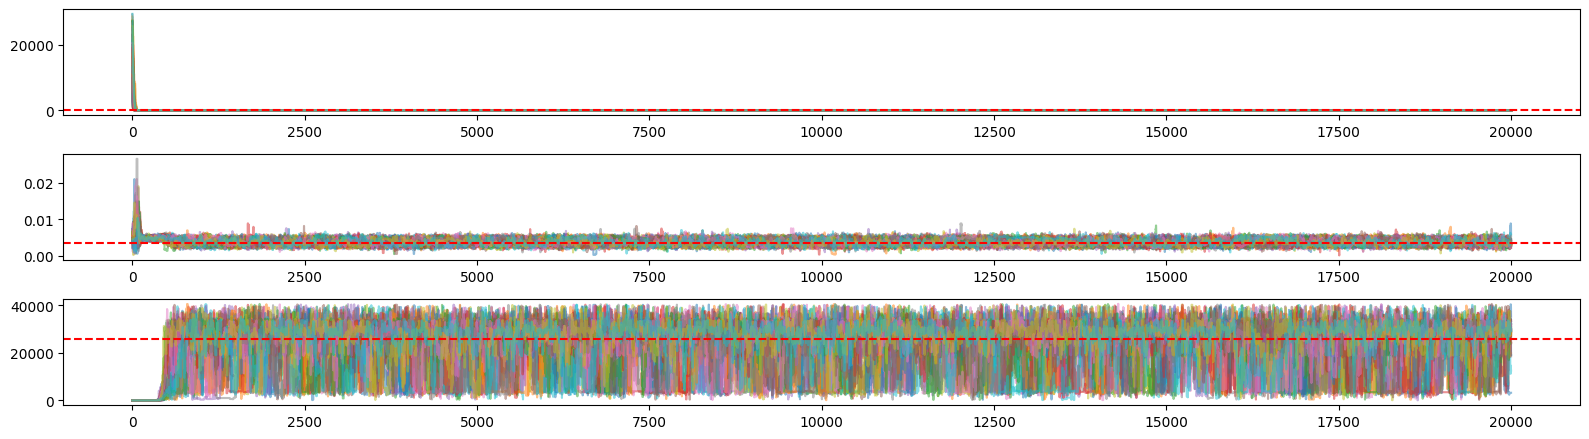

In [ ]:
# Plot unthinned chains with burn in
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler_1.get_chain()[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples_1[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.show()

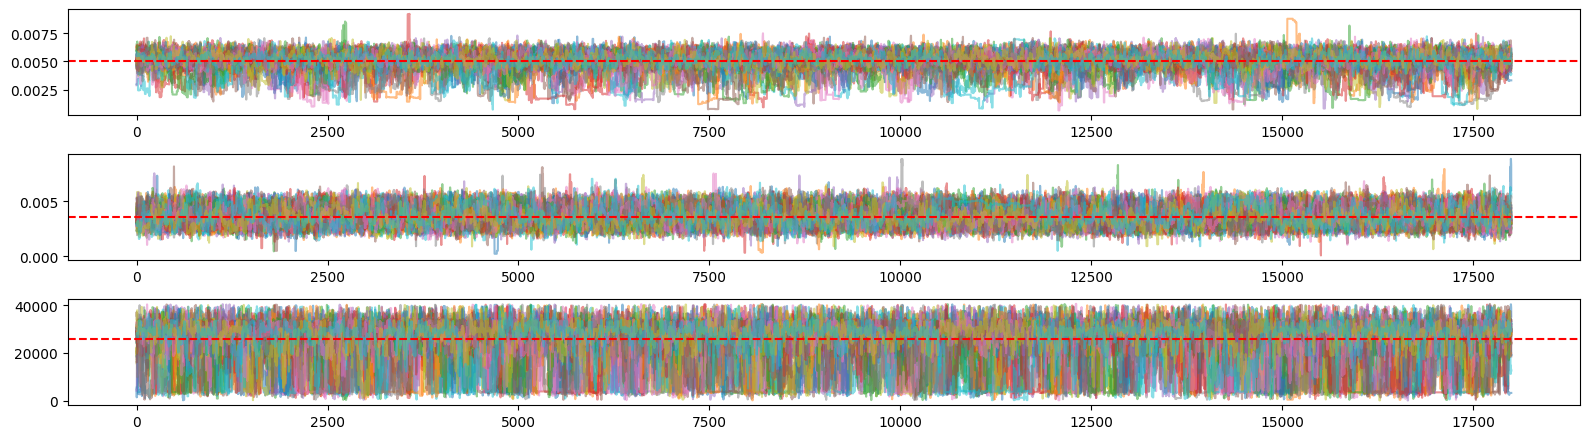

In [ ]:
# Plot with burn in removed
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler_1.get_chain(discard=nburnin)[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples_1[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.show()

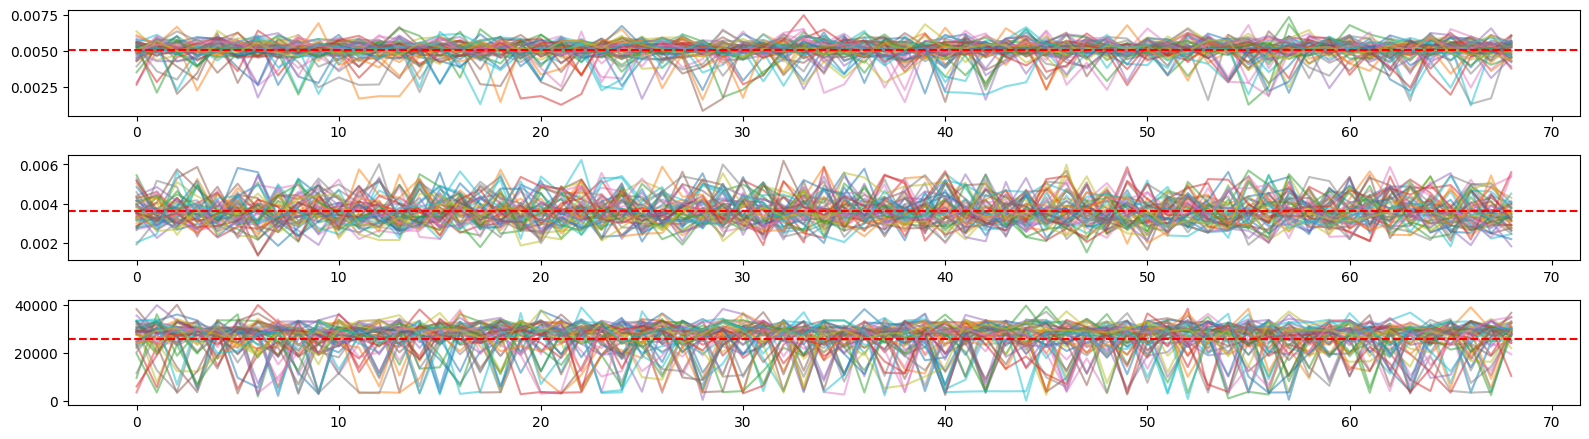

In [ ]:
# Plot with burn in removed and chains thinned
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler_1.get_chain(discard=nburnin, thin=thinning_factor_1)[:,:,n],alpha=0.5)
    plt.axhline(y=np.mean(samples_1[:, n]), color='red', linestyle='--')
plt.tight_layout()
plt.show()

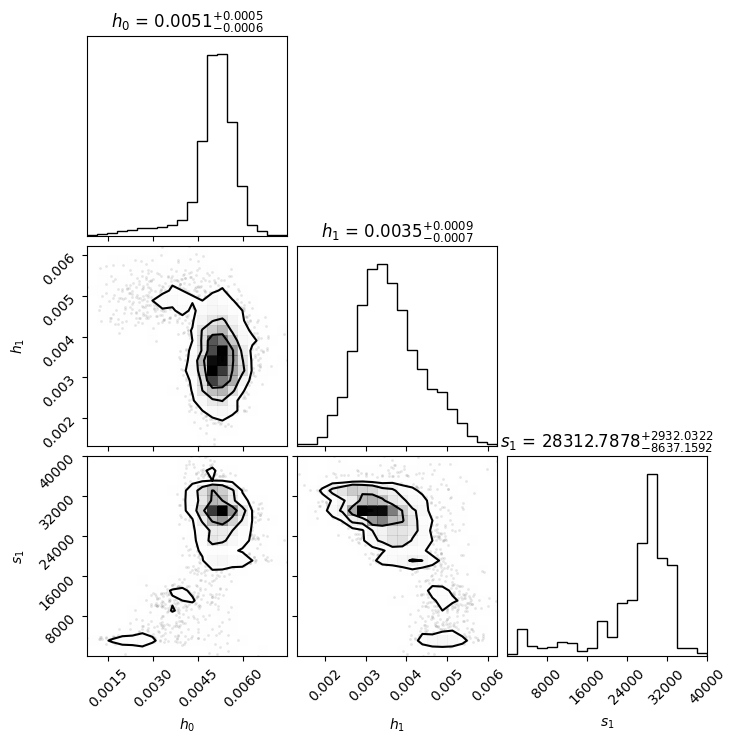

In [ ]:
import corner
labels = ["$h_0$", "$h_1$", "$s_1$"]
fig = corner.corner(samples_1.reshape(-1, ndim), labels=labels, show_titles=True, title_fmt=".4f", title_kwargs={"fontsize": 12})
plt.show()

In [56]:
import pymc

arviz_base not installed
arviz_stats not installed
arviz_plots not installed
/home/alex/projects/s2_coursework/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


### (b)

### (c)

### (d)

Here we use `dynesty` to perform nested sampling.

## References

1. [emcee ReadTheDocs](https://emcee.readthedocs.io/en/stable/)
2. [Ensemble samplers with affine invariance (Goodman and Weare)](https://msp.org/camcos/2010/5-1/p04.xhtml)
3. [zeus ReadTheDocs](https://zeus-mcmc.readthedocs.io/en/latest/index.html)
4. [Ensemble slice samplers](https://arxiv.org/pdf/2002.06212)
5. [zeus paper](https://arxiv.org/pdf/2105.03468)